In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import datasets
from scipy import stats
import joblib

# Load data
df = pd.read_csv("Nassau Candy Distributor.csv")

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)



Shape: (10194, 18)

Data types:
 Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID         int64
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Division              str
Region                str
Product ID            str
Product Name          str
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object


In [3]:
df.columns = df.columns.str.strip()  # Remove leading/trailing whitespace from column names 
# df.columns 


In [4]:

# Drop rows with critical nulls
df.dropna(subset=['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'], inplace=True)

In [5]:
print("\nNull counts:\n", df.isnull().sum())


Null counts:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64


In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [7]:
# Null/empty strings count karo
print("Empty strings:", (df['Order Date'] == '').sum())
print("Whitespace:   ", (df['Order Date'].str.strip() == '').sum())
print("Actual nulls: ", df['Order Date'].isnull().sum())

Empty strings: 0
Whitespace:    0
Actual nulls:  0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [9]:
# convert 'time' columns to datetime

df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', errors='coerce',dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', errors='coerce',dayfirst=True)
df['month'] = df['Order Date'].dt.month
df['day'] = df['Order Date'].dt.day
df['year'] = df['Order Date'].dt.year
df['order_quarter']   = df['Order Date'].dt.quarter

In [10]:
df[df['Order Date'].isnull()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Product ID,Product Name,Sales,Units,Gross Profit,Cost,month,day,year,order_quarter


In [11]:
# Step 3: lead_time_days nikalo
df['lead_time_days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['lead_time_days'] = df['lead_time_days'].clip(lower=0)  # negative fix

In [12]:
# Derived financial features
df['margin_pct']      = df['Gross Profit'] / df['Sales']          # profit margin %
df['cost_per_unit']   = df['Cost'] / df['Units']
df['revenue_per_unit']= df['Sales'] / df['Units']

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Row ID            10194 non-null  int64         
 1   Order ID          10194 non-null  str           
 2   Order Date        10194 non-null  datetime64[us]
 3   Ship Date         10194 non-null  datetime64[us]
 4   Ship Mode         10194 non-null  str           
 5   Customer ID       10194 non-null  int64         
 6   Country/Region    10194 non-null  str           
 7   City              10194 non-null  str           
 8   State/Province    10194 non-null  str           
 9   Postal Code       10194 non-null  str           
 10  Division          10194 non-null  str           
 11  Region            10194 non-null  str           
 12  Product ID        10194 non-null  str           
 13  Product Name      10194 non-null  str           
 14  Sales             10194 non-null 

In [14]:
numeric_data=['Sales', 'Units', 'Gross Profit', 'Cost', 'lead_time_days', 'margin_pct', 'cost_per_unit', 'revenue_per_unit']
categorical_data=['Ship Mode', 'Country/Region', 'City', 'State/Province', 'Division', 'Region', 'Product Name']

In [15]:
import plotly.express as px
def plot_numeric_distributions(df, numeric_cols):
    for col in numeric_cols:
        fig = px.box(df, y=col, color_discrete_sequence=['skyblue'])
        fig.update_layout(title=f'Distribution of {col}')
        fig.show()
        plt.show()



In [16]:
plot_numeric_distributions(df, numeric_data)

In [17]:
df[numeric_data].describe()

,Sales,Units,Gross Profit,Cost,lead_time_days,margin_pct,cost_per_unit,revenue_per_unit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,13.908537,3.791838,9.166451,4.742087,1320.841868,0.665140,1.241719,3.654257
std,11.341020,2.228317,6.643740,5.061647,262.444892,0.067210,0.871623,1.611875
min,1.250000,1.000000,0.250000,0.600000,904.000000,0.076923,0.600000,1.250000
25%,7.200000,2.000000,4.900000,2.400000,1271.000000,0.653333,1.100000,3.490000
50%,10.800000,3.000000,7.470000,3.600000,1274.000000,0.666667,1.140000,3.600000
75%,18.000000,5.000000,12.250000,5.700000,1638.000000,0.694444,1.200000,3.600000
max,260.000000,14.000000,130.000000,130.000000,1642.000000,0.800000,10.000000,20.000000


Text(0, 0.5, 'Frequency')

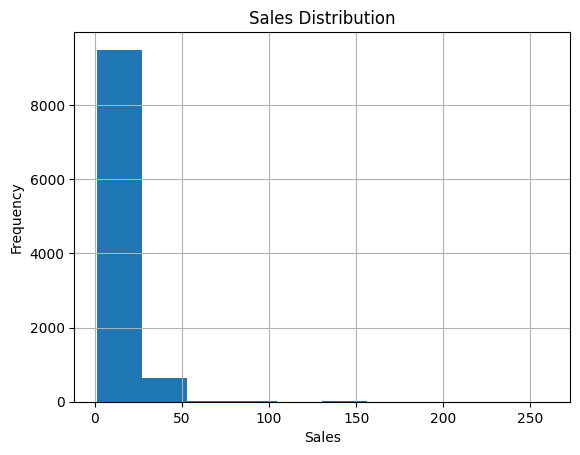

In [18]:
df['Sales'].hist()
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')

In [19]:
def plot_boxplot(df, column):
    for col in numeric_data:    
       fig, axes = plt.subplots(1, 1)
       sns.boxplot(y=df[col].dropna(), ax=axes, color='skyblue',medianprops=dict(color='red', linewidth=2)   ,meanline=True, showmeans=True)
       axes.set_title(f'Seaborn Boxplot of {col}')
       axes.set_ylabel(col)

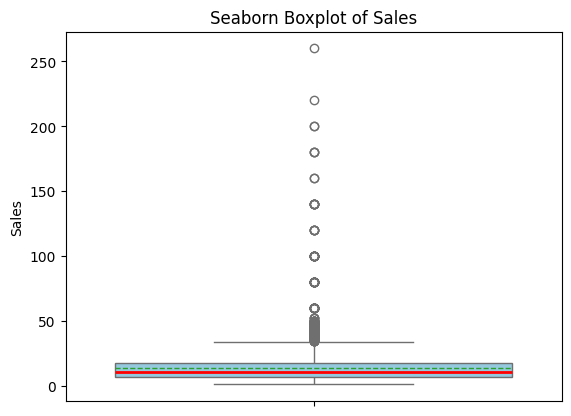

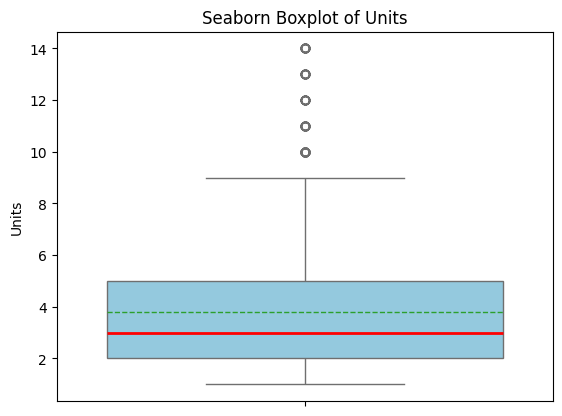

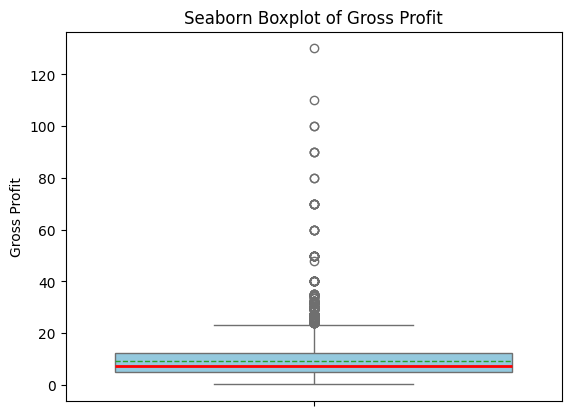

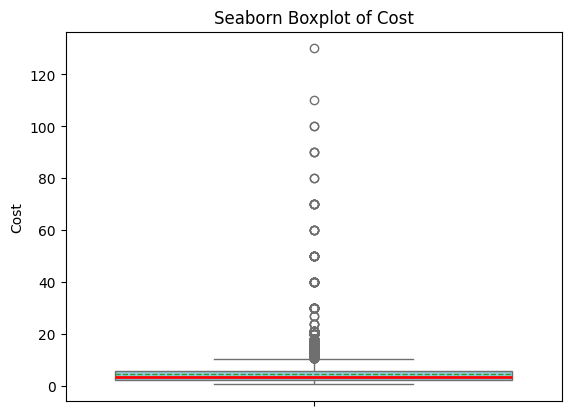

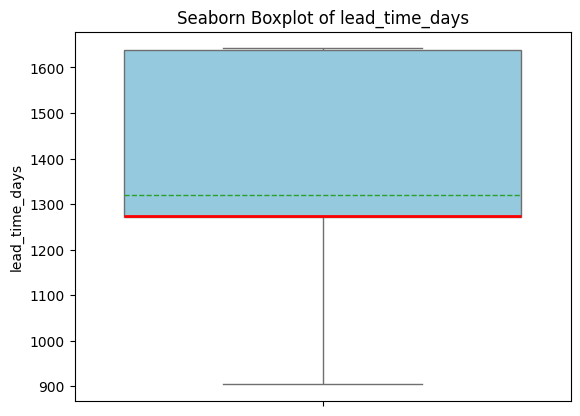

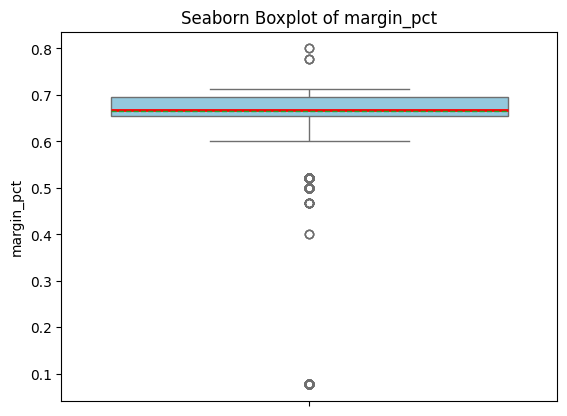

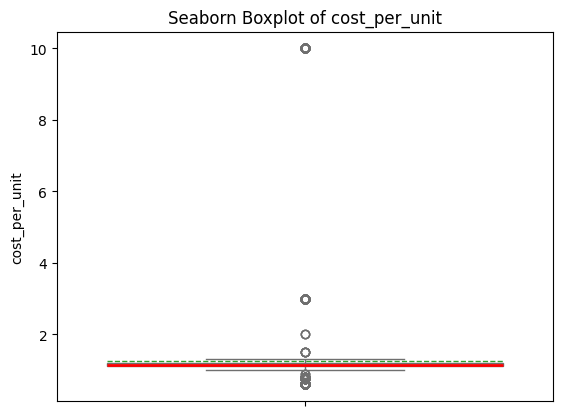

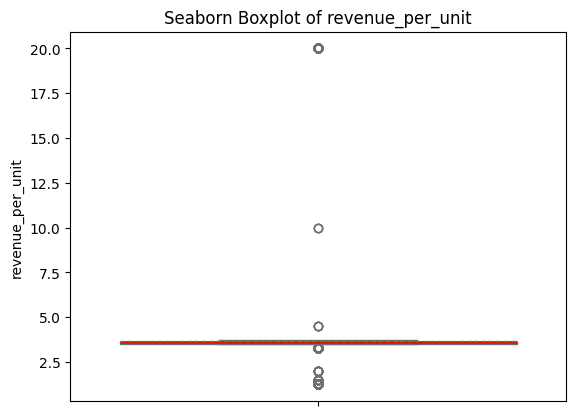

In [20]:
plot_boxplot(df, numeric_data)

In [21]:
# Detect outliers using IQR method

def detect_outliers_iqr(df,numeric_data):

    for col in numeric_data:    
       Q1 = df[col].quantile(0.25)
       Q3 = df[col].quantile(0.75)
       IQR = Q3 - Q1
       lower_bound = Q1 - 1.5 * IQR
       upper_bound = Q3 + 1.5 * IQR
       print(f"{col} - Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
       return df[(df[col] < lower_bound) | (df[col] > upper_bound)]


In [22]:
detect_outliers_iqr(df, numeric_data).shape

Sales - Lower Bound: -9.000000000000004, Upper Bound: 34.2


(245, 26)

In [23]:
# Clean dataset → strict removal

# def remove_outliers_strict(df, columns):
#     mask = pd.Series(True, index=df.index)

#     for col in columns:
#         Q1 = df[col].quantile(0.25)
#         Q3 = df[col].quantile(0.75)
#         IQR = Q3 - Q1

#         lower = Q1 - 1.5 * IQR
#         upper = Q3 + 1.5 * IQR

#         mask &= (df[col] >= lower) & (df[col] <= upper)

#     return df[mask]


# # call function
# remove_outliers_strict(df, numeric_data).shape

In [24]:
# # removed_outliers function ----- Important data → capping
def removed_outliers(df, column):
    for col in column:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower_bound, upper_bound )
    return df

 # call function
removed_outliers(df, numeric_data).head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Gross Profit,Cost,month,day,year,order_quarter,lead_time_days,margin_pct,cost_per_unit,revenue_per_unit
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,4.22,2.28,1,3,2024,1,909,0.649231,1.14,3.325
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,4.90,2.60,1,4,2024,1,909,0.653333,1.30,3.750
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,7.47,3.00,1,4,2024,1,909,0.713467,1.00,3.490
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,7.50,3.30,1,4,2024,1,909,0.694444,1.10,3.600
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,7.35,3.90,1,5,2024,1,912,0.653333,1.30,3.750


In [25]:
clean_df=removed_outliers(df, numeric_data)

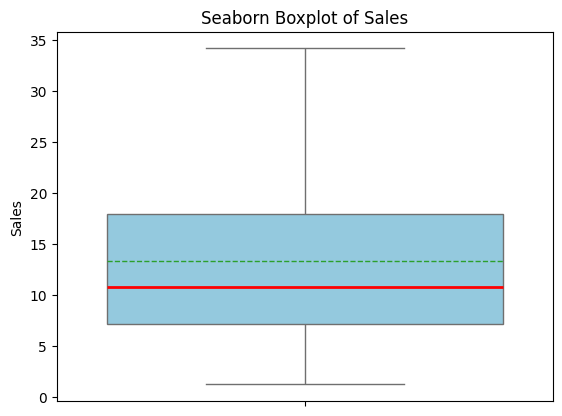

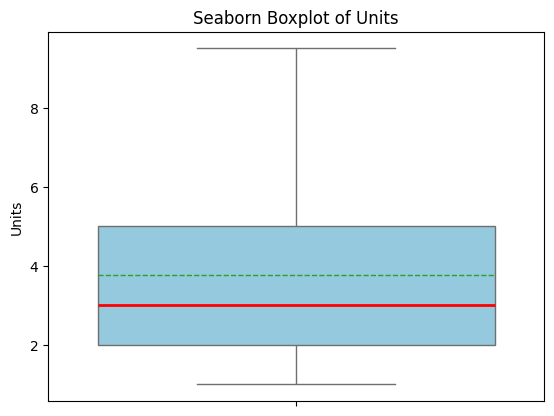

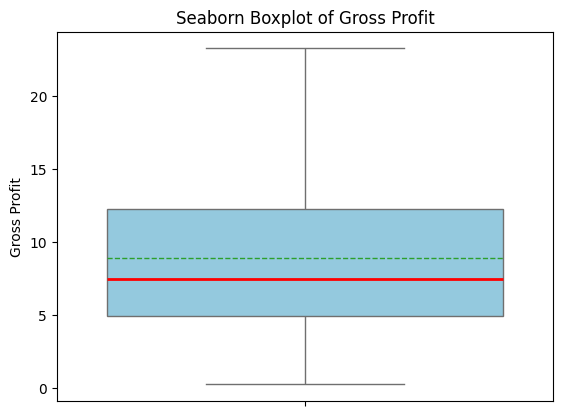

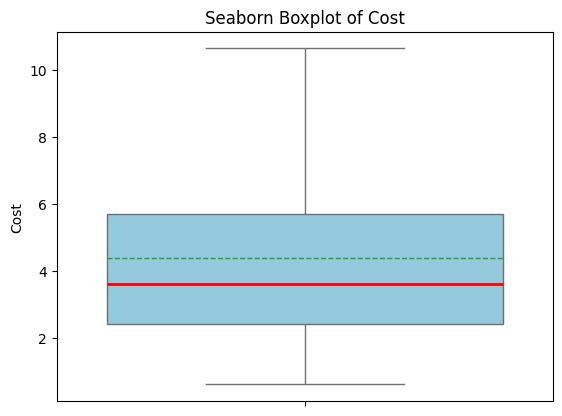

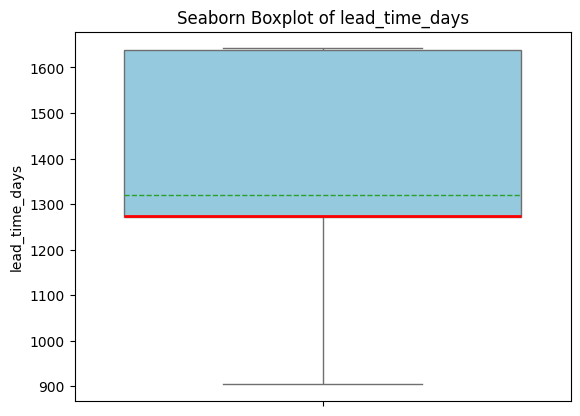

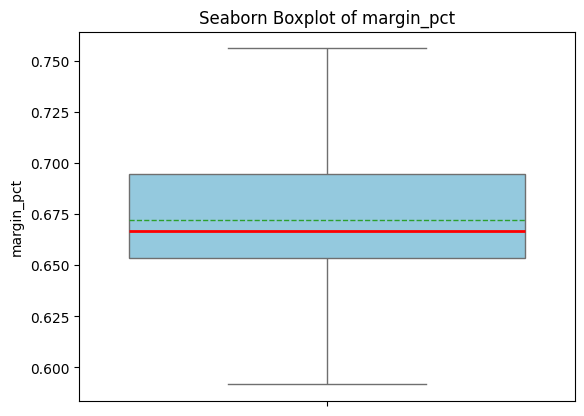

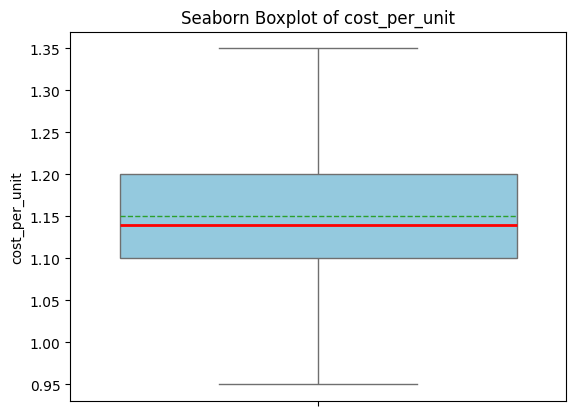

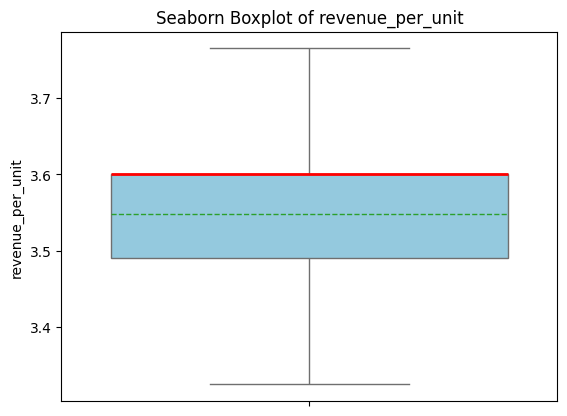

In [26]:
plot_boxplot(df, numeric_data)

In [27]:
# Percentage of data lost due to outlier removal
data_loss=(len(df)-len(clean_df)) / len(df)*100
print(f"Percentage of data lost due to outlier removal: {data_loss:.2f}%        ")  


Percentage of data lost due to outlier removal: 0.00%        


 Encode Numerical Variables

In [28]:
# StandardScaler → zero mean, unit variance (good for distance/regression models)
# MinMaxScaler  → [0,1] range (good for neural nets, KNN)

scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()

# Choose scaler based on downstream model

df_scaled = clean_df.copy()
# StandardScaler 

df_scaled[numeric_data] = scaler_std.fit_transform(clean_df[numeric_data])
joblib.dump(scaler_std, 'scaler_std.pkl')

# MinMaxScaler 

df_scaled_mm  = clean_df.copy()
df_scaled_mm[numeric_data]  = scaler_mm.fit_transform(clean_df[numeric_data])
joblib.dump(scaler_mm, 'scaler_mm.pkl')



['scaler_mm.pkl']

 Encode Categorical Variables

In [29]:
#  Encode Categorical Variables
category_cols = ['Ship Mode', 'Country/Region', 'City', 'State/Province', 'Division', 'Region', 'Product ID', 'Product Name']

In [30]:
# Clean category_cols chech white spaces, typos, etc.
for col in category_cols:
    print(f"------------------------------------Unique values in [{col}]:---------------------------------------")
    print(clean_df[col].unique())
    print()
    

------------------------------------Unique values in [Ship Mode]:---------------------------------------
<ArrowStringArray>
['Standard Class', 'First Class', 'Second Class', 'Same Day']
Length: 4, dtype: str

------------------------------------Unique values in [Country/Region]:---------------------------------------
<ArrowStringArray>
['United States', 'Canada']
Length: 2, dtype: str

------------------------------------Unique values in [City]:---------------------------------------
<ArrowStringArray>
[     'Houston',   'Naperville', 'Philadelphia',    'Henderson',
       'Athens',  'Los Angeles',   'Huntsville',       'Laredo',
  'Springfield',        'Dover',
 ...
      'Ontario',       'Renton',       'Canton',  'Summerville',
    'Gladstone',     'Whittier',      'Abilene',     'Palatine',
  'Port Orange',      'Danbury']
Length: 542, dtype: str

------------------------------------Unique values in [State/Province]:---------------------------------------
<ArrowStringArray>
[      

In [31]:
# Option A: One-Hot Encoding (for low-cardinality, no ordinal relationship)
df_One_Hot_Encoding = pd.get_dummies(df_scaled, columns=category_cols, drop_first=True)



In [32]:
df_One_Hot_Encoding 

,Row ID,Order ID,Order Date,Ship Date,Customer ID,Postal Code,Sales,Units,Gross Profit,Cost,...,Product Name_Laffy Taffy,Product Name_Lickable Wallpaper,Product Name_Nerds,Product Name_SweeTARTS,Product Name_Wonka Bar - Fudge Mallows,Product Name_Wonka Bar - Milk Chocolate,Product Name_Wonka Bar - Nutty Crunch Surprise,Product Name_Wonka Bar - Triple Dazzle Caramel,Product Name_Wonka Bar -Scrumdiddlyumptious,Product Name_Wonka Gum
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,103800,77095,-0.885062,-0.833610,-0.890858,-0.831371,...,False,False,False,False,False,True,False,False,False,False
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,112326,60540,-0.755497,-0.833610,-0.761603,-0.704361,...,False,False,False,False,False,False,False,True,False,False
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,112326,60540,-0.370686,-0.358805,-0.273092,-0.545599,...,False,False,False,False,False,False,True,False,False,False
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,112326,60540,-0.327930,-0.358805,-0.267389,-0.426527,...,False,False,False,False,False,False,False,False,True,False
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,141817,19143,-0.269625,-0.358805,-0.295902,-0.188383,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,10190,US-2024-143259-CHO-MIL-31000,2025-12-30,2030-06-26,143259,10009,-0.463974,-0.358805,-0.489785,-0.378898,...,False,False,False,False,False,True,False,False,False,False
10190,10191,US-2024-115427-CHO-NUT-13000,2025-12-30,2030-06-26,115427,94533,-0.822871,-0.833610,-0.746396,-0.942505,...,False,False,False,False,False,False,True,False,False,False
10191,10192,US-2024-156720-CHO-SCR-58000,2025-12-30,2030-06-26,156720,80538,-0.327930,-0.358805,-0.267389,-0.426527,...,False,False,False,False,False,False,False,False,True,False
10192,10193,US-2024-143259-CHO-TRI-54000,2025-12-30,2030-06-26,143259,10009,1.673861,1.540415,1.566902,1.875530,...,False,False,False,False,False,False,False,True,False,False


In [33]:
# Option B: Label Encoding (for tree-based models)
label_encoders = {}
df_Label_Encoding = df_scaled.copy()    
le = LabelEncoder()
for col in category_cols:
    df_Label_Encoding[col+'_enc'] = le.fit_transform(df_Label_Encoding[col])
    label_encoders[col] = le  # save encoder for future use
le



LabelEncoder()

In [34]:
# Option C: Target / Mean Encoding (for high-cardinality like product_id)
# Encodes each category as the mean of the target (e.g., margin)
target = "margin"
for col in ["product_id"]:
    means = df_scaled.groupby('Product ID')['margin_pct'].mean()
    df_scaled[f"{col}_target_enc"] = df_scaled['Product ID'].map(means)

# Fill NaN from unseen categories
df_scaled.fillna(df_scaled.mean(numeric_only=True), inplace=True)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Cost,month,day,year,order_quarter,lead_time_days,margin_pct,cost_per_unit,revenue_per_unit,product_id_target_enc
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,-0.831371,1,3,2024,1,-1.569328,-0.797322,-0.102807,-1.508124,-0.797322
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,-0.704361,1,4,2024,1,-1.569328,-0.652921,1.438114,1.370785,-0.652921
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,-0.545599,1,4,2024,1,-1.569328,1.463641,-1.451114,-0.390430,1.463641
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,-0.426527,1,4,2024,1,-1.569328,0.794091,-0.488038,0.354700,0.794091
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,-0.188383,1,5,2024,1,-1.557896,-0.652921,1.438114,1.370785,-0.652921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,10190,US-2024-143259-CHO-MIL-31000,2025-12-30,2030-06-26,Standard Class,143259,United States,New York City,New York,10009,...,-0.378898,12,30,2025,4,1.212345,-0.797322,-0.102807,-1.508124,-0.797322
10190,10191,US-2024-115427-CHO-NUT-13000,2025-12-30,2030-06-26,Standard Class,115427,United States,Fairfield,California,94533,...,-0.942505,12,30,2025,4,1.212345,1.463641,-1.451114,-0.390430,1.463641
10191,10192,US-2024-156720-CHO-SCR-58000,2025-12-30,2030-06-26,Standard Class,156720,United States,Loveland,Colorado,80538,...,-0.426527,12,30,2025,4,1.212345,0.794091,-0.488038,0.354700,0.794091
10192,10193,US-2024-143259-CHO-TRI-54000,2025-12-30,2030-06-26,Standard Class,143259,United States,New York City,New York,10009,...,1.875530,12,30,2025,4,1.212345,-0.652921,1.438114,1.370785,-0.652921


Text(0.5, 1.0, 'Margin Percentage Distribution')

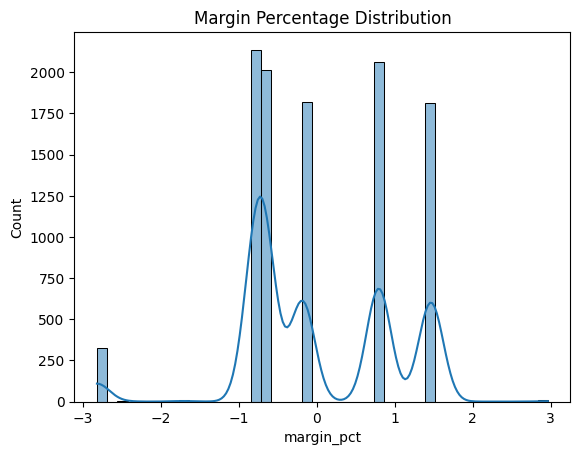

In [35]:
sns.histplot(df_scaled['margin_pct'], kde=True)
plt.title('Margin Percentage Distribution') 

In [36]:
sns.heatmap(df_scaled.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')


ValueError: could not convert string to float: 'US-2021-103800-CHO-MIL-31000'